Data length:  951358
Detected spikes:  21693
Spikes after merge:  8840
Waveforms:  (8840, 40)
Saved: H:\Data\Ge\MEA_export\31_health_DoubleEdge_S3.6–20.6deg_V6.9degps_dt500ms_grayblack_whiteblack_DIRSWEEP(45,11s, 88s)_1min pre_285s sti_10min re\data0000_spikes_spikes.csv


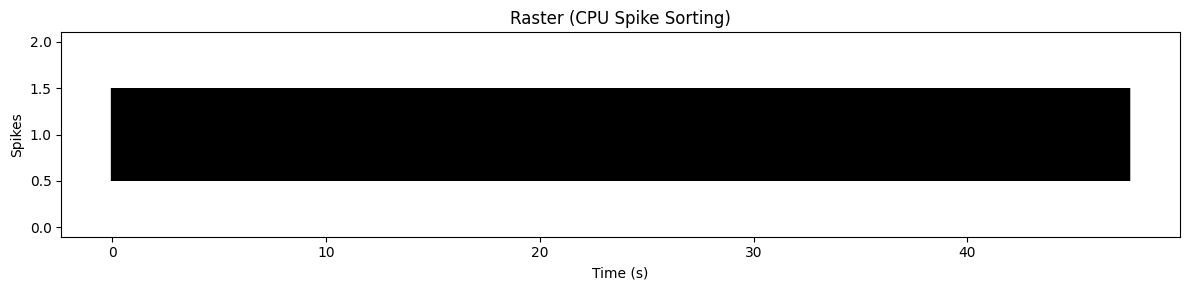

In [11]:
import os
import numpy as np
import pandas as pd
from scipy.signal import butter, filtfilt
from sklearn.cluster import KMeans
import matplotlib.pyplot as plt

# ====================================
# 文件路径修改为你的真实路径
# ====================================
FILE = r"H:\Data\Ge\MEA_export\31_health_DoubleEdge_S3.6–20.6deg_V6.9degps_dt500ms_grayblack_whiteblack_DIRSWEEP(45,11s, 88s)_1min pre_285s sti_10min re\data0000_spikes.csv"
FS = 20000  # Hz 采样率（你的实验是 20kHz）

# ========== 1. Load raw data ==========
df = pd.read_csv(FILE, header=None)
if df.shape[1] == 3:
    # [timestamp, ch, voltage]
    sig = df.iloc[:, 2].values.astype(np.float32)
else:
    # 单通道 txt
    sig = df.iloc[:, 0].values.astype(np.float32)

print("Data length: ", len(sig))

# ========== 2. Band-pass (spikes 300–3000Hz) ==========
def bandpass(x, fs, low=300, high=3000, order=3):
    b, a = butter(order, [low/(fs/2), high/(fs/2)], btype="band")
    return filtfilt(b, a, x)

sig_bp = bandpass(sig, FS)

# ========== 3. Detect spikes (MAD-threshold) ==========
med = np.median(sig_bp)
mad = np.median(np.abs(sig_bp - med))
thr = med - 4.5 * mad  # negative spikes

spike_idx = np.where(sig_bp < thr)[0]
print("Detected spikes: ", len(spike_idx))

# 合并过密点
refractory = int(0.001 * FS)  # 1ms
clean_idx = [spike_idx[0]]
for i in spike_idx[1:]:
    if i - clean_idx[-1] > refractory:
        clean_idx.append(i)
clean_idx = np.array(clean_idx)
print("Spikes after merge: ", len(clean_idx))

# ========== 4. Extract waveform ==========
win = int(0.001 * FS)  # ±1ms
waves = []
valid_idx = []
for i in clean_idx:
    if i - win >= 0 and i + win < len(sig_bp):
        waves.append(sig_bp[i-win:i+win])
        valid_idx.append(i)
waves = np.array(waves)
valid_idx = np.array(valid_idx)
print("Waveforms: ", waves.shape)

# ========== 5. Clustering (2–3类，自动判断) ==========
n_clusters = 2 if waves.shape[0] < 200 else 3
kmeans = KMeans(n_clusters=n_clusters, random_state=0).fit(waves)
labels = kmeans.labels_

# 时间戳 (sec)
spike_times = valid_idx / FS

# ========== 6. Save results ==========
out_csv = FILE.replace(".csv", "_spikes.csv")
pd.DataFrame({
    "time_s": spike_times,
    "label": labels
}).to_csv(out_csv, index=False)

print("Saved:", out_csv)

# ========== 7. Raster plot ==========
plt.figure(figsize=(12,3))
plt.eventplot(spike_times, colors="k")
plt.xlabel("Time (s)")
plt.ylabel("Spikes")
plt.title("Raster (CPU Spike Sorting)")
plt.tight_layout()
plt.savefig(FILE.replace(".csv", "_raster_cpu.png"), dpi=300)
plt.show()


In [4]:
import pandas as pd
csv_path = r"H:\Data\Ge\MEA_export\30_health_baseline for 31-39\data0000_spikes_sorted.csv"

df = pd.read_csv(csv_path)
print(df.columns)
print(df.head())


Index(['time_s', 'cluster'], dtype='object')
    time_s  cluster
0  0.00160        0
1  0.00440        0
2  0.01090        0
3  0.01325        1
4  0.01540        1


In [5]:
import os
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt

BASE = r"H:\Data\Ge\MEA_export\30_health_baseline for 31-39"
FS = 20000  # Hz

# ======================
#  QC 指标函数
# ======================
def isi_violation(st, min_isi=1e-3):
    isi = np.diff(st)
    if len(isi)==0: return np.nan
    return np.sum(isi < min_isi) / len(isi) * 100

def estimate_SNR(wfs):
    # Peak-to-peak / NoiseStd
    if wfs is None or len(wfs)==0: return np.nan
    mean_wf = wfs.mean(0)
    p2p = mean_wf.max() - mean_wf.min()
    noise = np.median(np.std(wfs - mean_wf, axis=0))
    return p2p / noise if noise>0 else np.nan

def classify_condition(fname):
    fname = fname.lower()
    if "pre" in fname: return "Pre"
    if "post" in fname: return "Post"
    return "Unknown"

# ======================
# 处理一个文件
# ======================
def process_file(csv_path):
    df = pd.read_csv(csv_path)
    fname = os.path.basename(csv_path).replace(".csv","")
    cond = classify_condition(fname)

    fig_dir = os.path.join(os.path.dirname(csv_path), "QC_figs")
    os.makedirs(fig_dir, exist_ok=True)

    clusters = sorted(df["cluster"].unique())
    t_all = df["time_s"].values
    dur = t_all.max() - t_all.min()

    # 找 waveform 文件（可选）
    wf_path = csv_path.replace("_sorted.csv", "_wf.npy")
    has_wf = os.path.exists(wf_path)
    wfs_all = np.load(wf_path) if has_wf else None

    stats = []

    # ===== Raster =====
    plt.figure(figsize=(14,5))
    for cid in clusters:
        st = df[df.cluster==cid]["time_s"].values
        plt.vlines(st, cid-0.4, cid+0.4)
    plt.xlabel("Time (s)")
    plt.ylabel("Neuron ID")
    plt.title(f"Raster: {fname}  ({cond})")
    plt.savefig(os.path.join(fig_dir, f"{fname}_raster.png"), dpi=200)
    plt.close()

    # ===== Mean waveform =====
    if has_wf:
        plt.figure(figsize=(14,5))
        for cid in clusters:
            idx = df[df.cluster==cid].index.values
            wfs = wfs_all[idx, :]
            plt.plot(wfs.mean(0), label=f"Neuron {cid} (n={len(idx)})")
        plt.legend()
        plt.title(f"Mean Waveforms: {fname}  ({cond})")
        plt.savefig(os.path.join(fig_dir, f"{fname}_waveforms.png"), dpi=200)
        plt.close()

    # ===== QC & FR =====
    for cid in clusters:
        st = df[df.cluster==cid]["time_s"].values

        fr = len(st) / dur
        isi_v = isi_violation(st)

        if has_wf:
            idx = df[df.cluster==cid].index.values
            snr = estimate_SNR(wfs_all[idx,:])
        else:
            snr = np.nan

        stats.append([fname, cond, cid, len(st), fr, isi_v, snr])

    out = pd.DataFrame(stats, 
        columns=["file","condition","cluster","spike_count",
                 "firing_rate_Hz","ISI_violation_%","SNR_est"])
    
    out_path = csv_path.replace(".csv", "_QC.csv")
    out.to_csv(out_path, index=False)

    print("✔ Done:", fname)
    return out


# ======================
# 批处理整个目录
# ======================
all_stats = []
for root, _, files in os.walk(BASE):
    for f in files:
        if f.endswith("_sorted.csv"):
            stats = process_file(os.path.join(root,f))
            all_stats.append(stats)

final = pd.concat(all_stats, ignore_index=True)
final.to_csv(os.path.join(BASE,"ALL_QC_results.csv"), index=False)

print("\n🎯 全部完成！")
print("📊 汇总文件:", os.path.join(BASE,"ALL_QC_results.csv"))
print("📎 结果图:", os.path.join(BASE, "QC_figs"))


✔ Done: data0000_spikes_sorted

🎯 全部完成！
📊 汇总文件: H:\Data\Ge\MEA_export\30_health_baseline for 31-39\ALL_QC_results.csv
📎 结果图: H:\Data\Ge\MEA_export\30_health_baseline for 31-39\QC_figs


In [20]:
import os
import numpy as np
import pandas as pd
import unicodedata
from scipy.signal import butter, filtfilt
from sklearn.cluster import KMeans
import matplotlib.pyplot as plt

ROOT = r"H:\Data\Ge\MEA_export"
FS = 20000  # Hz Sampling Rate

# =============================
# Utility: normalize unicode path （修复 “–” 路径错误）
# =============================
def norm_path(p):
    return unicodedata.normalize("NFKC", p)


# =============================
# Band-pass filter for spike detection
# =============================
def bandpass(x, fs, low=300, high=3000, order=3):
    b, a = butter(order, [low/(fs/2), high/(fs/2)], btype="band")
    return filtfilt(b, a, x)


# =============================
# Spike Sorting for SINGLE file
# =============================
def sort_spikes(FILE):
    FILE = norm_path(FILE)
    print("\n📌 Processing:", FILE)

    # ---- Load raw data
    df = pd.read_csv(FILE, header=None)
    if df.shape[1] == 3:
        sig = df.iloc[:, 2].values.astype(np.float32)
    else:
        sig = df.iloc[:, 0].values.astype(np.float32)

    print("Data length:", len(sig))

    # ---- Filter & MAD threshold spike detection
    sig_bp = bandpass(sig, FS)
    med = np.median(sig_bp)
    mad = np.median(np.abs(sig_bp - med))
    thr = med - 4.5 * mad
    spike_idx = np.where(sig_bp < thr)[0]
    print("Detected spikes:", len(spike_idx))

    if len(spike_idx) == 0:
        print("⚠ No spikes found — skipping.")
        return

    # ---- Merge close spikes (<1ms)
    refractory = int(0.001 * FS)
    clean = [spike_idx[0]]
    for s in spike_idx[1:]:
        if s - clean[-1] > refractory:
            clean.append(s)
    clean = np.array(clean)
    print("Spikes after merge:", len(clean))

    # ---- Extract waveforms
    win = int(0.001 * FS)  # 1ms window
    waves, valid = [], []
    for s in clean:
        if s - win >= 0 and s + win < len(sig_bp):
            waves.append(sig_bp[s-win:s+win])
            valid.append(s)
    waves = np.array(waves)
    valid = np.array(valid)
    print("Waveforms:", waves.shape)

    if waves.shape[0] < 5:
        print("⚠ Too few waveforms — skip clustering.")
        return

    # ---- Spike Clustering
    n_clusters = 2 if waves.shape[0] < 200 else 3
    km = KMeans(n_clusters=n_clusters, random_state=0).fit(waves)
    labels = km.labels_
    spike_times = valid / FS

    # ---- Save sorted result
    out_csv = FILE.replace(".csv", "_spikes.csv")
    pd.DataFrame({
        "time_s": spike_times,
        "cluster": labels
    }).to_csv(out_csv, index=False)
    print("💾 Saved sorted:", out_csv)

    # ---- Raster plot
    plt.figure(figsize=(12,3))
    for cid in sorted(set(labels)):
        st = spike_times[labels == cid]
        plt.vlines(st, cid-0.4, cid+0.4)
    plt.xlabel("Time (s)")
    plt.ylabel("Cluster ID")
    plt.title("Raster (CPU Sorting)")
    plt.tight_layout()
    plt.savefig(FILE.replace(".csv", "_raster_cpu.png"), dpi=300)
    plt.close()

    # ---- Mean waveform
    plt.figure()
    for cid in sorted(set(labels)):
        idx = np.where(labels == cid)[0]
        plt.plot(waves[idx].mean(0), label=f"C{cid}(n={len(idx)})")
    plt.legend()
    plt.title("Mean Waveforms")
    plt.tight_layout()
    plt.savefig(FILE.replace(".csv", "_waveform.png"), dpi=300)
    plt.close()

    print("🧠 DONE:", os.path.basename(FILE))


# =============================
# Batch run on ALL “health” data
# =============================
def batch_sort():
    count = 0
    for root, dirs, files in os.walk(ROOT):
        if "health" not in root.lower():
            continue
        for f in files:
            if f == "data0000_spikes.csv":
                sort_spikes(os.path.join(root, f))
                count += 1
    print(f"\n🎯 ALL DONE! Sorted {count} files.\n")

batch_sort()



📌 Processing: H:\Data\Ge\MEA_export\30_health_baseline for 31-39\data0000_spikes.csv
Data length: 281288
Detected spikes: 10384
Spikes after merge: 3995
Waveforms: (3995, 40)
💾 Saved sorted: H:\Data\Ge\MEA_export\30_health_baseline for 31-39\data0000_spikes_spikes.csv
🧠 DONE: data0000_spikes.csv

📌 Processing: H:\Data\Ge\MEA_export\31_health_DoubleEdge_S3.6–20.6deg_V6.9degps_dt500ms_grayblack_whiteblack_DIRSWEEP(45,11s, 88s)_1min pre_285s sti_10min re\data0000_spikes.csv
Data length: 951358
Detected spikes: 21693
Spikes after merge: 8840
Waveforms: (8840, 40)
💾 Saved sorted: H:\Data\Ge\MEA_export\31_health_DoubleEdge_S3.6–20.6deg_V6.9degps_dt500ms_grayblack_whiteblack_DIRSWEEP(45,11s, 88s)_1min pre_285s sti_10min re\data0000_spikes_spikes.csv
🧠 DONE: data0000_spikes.csv

📌 Processing: H:\Data\Ge\MEA_export\32_health_SingleEdge_V13.8degps_STEP7_T~8s_BACKFORTH_dt500ms_whiteblack_DIRSWEEP_STAGED(45,13s, 104s)_1min pre_334s sti_10min re\data0000_spikes.csv
Data length: 1161836
Detected sp

In [21]:
import os
import numpy as np
import pandas as pd
import unicodedata
from scipy.signal import butter, filtfilt
from sklearn.cluster import KMeans
import matplotlib.pyplot as plt

ROOT = r"H:\Data\Ge\MEA_export"
FS = 20000  # sampling rate

# ======= Stage timing (sec) =======
T_PRE  = 60
T_STIM = 285
T_REC  = 600


def norm_path(p):
    return unicodedata.normalize("NFKC", p)


def bandpass(x, fs, low=300, high=3000, order=3):
    b, a = butter(order, [low/(fs/2), high/(fs/2)], btype="band")
    return filtfilt(b, a, x)


def compute_ISI_violation(stamps, min_isi=1e-3):
    isi = np.diff(stamps)
    if len(isi) == 0: return np.nan
    return (isi < min_isi).sum() / len(isi) * 100


def compute_SNR(waves):
    if waves.shape[0] == 0: return np.nan
    mean_wf = waves.mean(0)
    peak = np.max(np.abs(mean_wf))
    noise = np.std(waves[:, :5])
    return peak / noise


def stage_firing_rate(times):
    return {
        "FR_pre" : np.sum(times < T_PRE) / T_PRE,
        "FR_stim": np.sum((times >= T_PRE) & (times < T_PRE+T_STIM)) / T_STIM,
        "FR_rec" : np.sum(times >= T_PRE+T_STIM) / T_REC
    }


def sort_spikes(FILE):
    FILE = norm_path(FILE)
    print("\n📌 Processing:", FILE)

    # load raw signal
    df = pd.read_csv(FILE, header=None)
    sig = df.iloc[:, -1].values.astype(np.float32)
    print("Data length:", len(sig))

    # detect spikes
    sig_bp = bandpass(sig, FS)
    med = np.median(sig_bp)
    mad = np.median(np.abs(sig_bp - med))
    thr = med - 4.5 * mad
    spike_idx = np.where(sig_bp < thr)[0]
    if len(spike_idx) == 0:
        print("⚠  No spikes, skip.")
        return

    refractory = int(0.001 * FS)
    clean = [spike_idx[0]]
    for s in spike_idx[1:]:
        if s - clean[-1] > refractory:
            clean.append(s)
    clean = np.array(clean)

    # waveforms
    win = int(0.001 * FS)
    waves, valid = [], []
    for s in clean:
        if s - win >= 0 and s + win < len(sig_bp):
            waves.append(sig_bp[s-win:s+win])
            valid.append(s)
    waves = np.array(waves)
    valid = np.array(valid)
    times = valid / FS

    # clustering
    n_clusters = 2 if waves.shape[0] < 200 else 3
    km = KMeans(n_clusters=n_clusters, random_state=0).fit(waves)
    labels = km.labels_

    # ==== SAVE BASIC SPIKE OUTPUT ====
    sorted_csv = FILE.replace(".csv", "_spikes.csv")
    pd.DataFrame({"time_s": times, "cluster": labels}).to_csv(sorted_csv, index=False)
    print("💾 Sorted saved:", sorted_csv)

    # ==== Standard output ====
    out_dir = os.path.join(os.path.dirname(FILE), "sorted_output")
    os.makedirs(out_dir, exist_ok=True)
    np.save(os.path.join(out_dir, "spike_times.npy"), times)
    np.save(os.path.join(out_dir, "spike_clusters.npy"), labels)

    # ==== Per-cluster QC & FR ====
    qc = []
    plot_dir = os.path.join(os.path.dirname(FILE), "qc_plots")
    os.makedirs(plot_dir, exist_ok=True)

    for cid in sorted(set(labels)):
        idx = np.where(labels == cid)[0]
        t = times[idx]
        w = waves[idx]

        isi_v = compute_ISI_violation(t)
        snr = compute_SNR(w)
        fr_dict = stage_firing_rate(t)

        qc.append([cid, len(t), isi_v, snr,
                   fr_dict["FR_pre"], fr_dict["FR_stim"], fr_dict["FR_rec"]])

        # mean waveform
        plt.figure()
        plt.plot(w.mean(0))
        plt.title(f"Cluster {cid}  n={len(t)}  SNR={snr:.2f}")
        plt.tight_layout()
        plt.savefig(f"{plot_dir}/cluster_{cid}_waveform.png", dpi=200)
        plt.close()

        # raster
        plt.figure(figsize=(10,2))
        plt.vlines(t, cid-0.3, cid+0.3)
        plt.title(f"Raster {cid}")
        plt.xlabel("Time (s)")
        plt.tight_layout()
        plt.savefig(f"{plot_dir}/cluster_{cid}_raster.png", dpi=200)
        plt.close()

    qc_df = pd.DataFrame(qc, columns=[
        "cluster","spike_count","ISI_violation_%","SNR",
        "FR_pre_Hz","FR_stim_Hz","FR_rec_Hz"])
    qc_df.to_csv(os.path.join(os.path.dirname(FILE),"cluster_quality.csv"), index=False)

    print("📊 QC + FR saved.")
    print(qc_df)
    print("🧠 DONE:", os.path.basename(FILE))


# ============= Batch run for ALL “health” data =============
count = 0
for root, dirs, files in os.walk(ROOT):
    if "health" not in root.lower():
        continue
    for f in files:
        if f == "data0000_spikes.csv":
            sort_spikes(os.path.join(root, f))
            count += 1

print(f"\n🎯 ALL DONE — processed {count} files.\n")



📌 Processing: H:\Data\Ge\MEA_export\30_health_baseline for 31-39\data0000_spikes.csv
Data length: 281288
💾 Sorted saved: H:\Data\Ge\MEA_export\30_health_baseline for 31-39\data0000_spikes_spikes.csv
📊 QC + FR saved.
   cluster  spike_count  ISI_violation_%       SNR  FR_pre_Hz  FR_stim_Hz  \
0        0          839              0.0  2.756867  13.983333         0.0   
1        1          705              0.0  2.890947  11.750000         0.0   
2        2         2451              0.0  2.888202  40.850000         0.0   

   FR_rec_Hz  
0        0.0  
1        0.0  
2        0.0  
🧠 DONE: data0000_spikes.csv

📌 Processing: H:\Data\Ge\MEA_export\31_health_DoubleEdge_S3.6–20.6deg_V6.9degps_dt500ms_grayblack_whiteblack_DIRSWEEP(45,11s, 88s)_1min pre_285s sti_10min re\data0000_spikes.csv
Data length: 951358
💾 Sorted saved: H:\Data\Ge\MEA_export\31_health_DoubleEdge_S3.6–20.6deg_V6.9degps_dt500ms_grayblack_whiteblack_DIRSWEEP(45,11s, 88s)_1min pre_285s sti_10min re\data0000_spikes_spikes.csv


In [22]:
import os
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
from scipy import stats

# ===========================
# 根目录：就是你之前用的 MEA_export
# ===========================
ROOT = r"H:\Data\Ge\MEA_export"

# 输出汇总表保存位置
SUMMARY_CSV = os.path.join(ROOT, "health_FR_summary.csv")

all_rows = []

print("🔍 扫描包含 'health' 的 cluster_quality.csv ...")
for root, dirs, files in os.walk(ROOT):
    if "health" not in root.lower():
        continue
    if "cluster_quality.csv" in files:
        rec_name = os.path.basename(root)
        csv_path = os.path.join(root, "cluster_quality.csv")
        print("  ➕ 发现记录：", rec_name)

        df = pd.read_csv(csv_path)

        # 要求 cluster_quality.csv 至少有这些列
        required_cols = {
            "cluster", "spike_count",
            "FR_pre_Hz", "FR_stim_Hz", "FR_rec_Hz",
            "ISI_violation_%", "SNR"
        }
        if not required_cols.issubset(df.columns):
            print("  ⚠ 缺少必需列，跳过：", csv_path)
            continue

        # 为每一个 cluster 生成唯一 neuron_id
        for _, row in df.iterrows():
            neuron_id = f"{rec_name}_c{int(row['cluster'])}"
            all_rows.append({
                "recording": rec_name,
                "cluster": int(row["cluster"]),
                "neuron_id": neuron_id,
                "spike_count": row["spike_count"],
                "FR_pre_Hz": row["FR_pre_Hz"],
                "FR_stim_Hz": row["FR_stim_Hz"],
                "FR_rec_Hz": row["FR_rec_Hz"],
                "ISI_violation_%": row["ISI_violation_%"],
                "SNR": row["SNR"],
            })

# ===========================
# 1. 汇总成大表
# ===========================
if not all_rows:
    print("❌ 没有找到任何 health 相关的 cluster_quality.csv，检查路径/脚本。")
    raise SystemExit

summary = pd.DataFrame(all_rows)
summary.to_csv(SUMMARY_CSV, index=False, encoding="utf-8-sig")
print(f"\n✅ 汇总完成，共 {len(summary)} 个 putative units")
print("  已保存汇总表：", SUMMARY_CSV)

# 只保留至少有若干 spikes 的单元（可选）
summary = summary[summary["spike_count"] > 50].reset_index(drop=True)

# 方便后面使用
FR_pre  = summary["FR_pre_Hz"].values
FR_stim = summary["FR_stim_Hz"].values
FR_rec  = summary["FR_rec_Hz"].values
SNR     = summary["SNR"].values
ISI_v   = summary["ISI_violation_%"].values
neuron_ids = summary["neuron_id"].values

# ===========================
# 2. FR Heatmap (Pre / Stim / Rec)
# ===========================
print("\n🎨 绘制 FR heatmap ...")

FR_matrix = np.vstack([FR_pre, FR_stim, FR_rec]).T   # shape: (n_units, 3)

# 单位按 Pre FR 排序，便于观察
order = np.argsort(FR_pre)
FR_sorted = FR_matrix[order, :]
ids_sorted = neuron_ids[order]

plt.figure(figsize=(6, max(4, len(FR_sorted) * 0.15)))
im = plt.imshow(FR_sorted, aspect="auto", origin="lower")
plt.colorbar(im, label="Firing rate (Hz)")

plt.yticks(
    ticks=np.arange(len(ids_sorted)),
    labels=ids_sorted,
    fontsize=6
)
plt.xticks(
    ticks=[0, 1, 2],
    labels=["Pre", "Stim", "Rec"]
)
plt.title("Health units – Firing rate heatmap (Pre / Stim / Rec)")
plt.tight_layout()
heatmap_path = os.path.join(ROOT, "health_FR_heatmap.png")
plt.savefig(heatmap_path, dpi=300)
plt.close()
print("  ✅ 已保存：", heatmap_path)

# ===========================
# 3. Line plot：单元可塑性变化 + 均值 ± SEM
# ===========================
print("🎨 绘制 FR line plot ...")

stages = np.array([0, 1, 2])
FR_all = FR_matrix   # (n_units, 3)

plt.figure(figsize=(6, 4))

# 每个单元一条线（淡色）
for i in range(FR_all.shape[0]):
    plt.plot(stages, FR_all[i, :], alpha=0.2)

# 计算均值和 SEM
mean_FR = FR_all.mean(axis=0)
sem_FR  = FR_all.std(axis=0, ddof=1) / np.sqrt(FR_all.shape[0])

plt.errorbar(
    stages, mean_FR, yerr=sem_FR,
    fmt="-o", linewidth=2, capsize=5,
    label=f"Mean ± SEM (n={FR_all.shape[0]})"
)

plt.xticks(stages, ["Pre", "Stim", "Rec"])
plt.ylabel("Firing rate (Hz)")
plt.title("Firing rate change per unit (health)")
plt.legend()
plt.tight_layout()
line_path = os.path.join(ROOT, "health_FR_lineplot.png")
plt.savefig(line_path, dpi=300)
plt.close()
print("  ✅ 已保存：", line_path)

# ===========================
# 4. Boxplot + 统计检验
# ===========================
print("🎨 绘制 FR boxplot + 统计 ...")

plt.figure(figsize=(6, 4))
plt.boxplot(
    [FR_pre, FR_stim, FR_rec],
    labels=["Pre", "Stim", "Rec"],
    showmeans=True
)
plt.ylabel("Firing rate (Hz)")
plt.title("FR distribution – Pre vs Stim vs Rec (health)")
plt.tight_layout()
box_path = os.path.join(ROOT, "health_FR_boxplot.png")
plt.savefig(box_path, dpi=300)
plt.close()
print("  ✅ 已保存：", box_path)

# 统计检验（只在有多于 3 个单元时才做）
if len(FR_pre) > 3:
    print("\n📊 统计检验（Wilcoxon 配对）:")
    try:
        w_pre_stim = stats.wilcoxon(FR_pre, FR_stim, zero_method="wilcox", alternative="two-sided")
        w_pre_rec  = stats.wilcoxon(FR_pre, FR_rec,  zero_method="wilcox", alternative="two-sided")
        w_stim_rec = stats.wilcoxon(FR_stim, FR_rec, zero_method="wilcox", alternative="two-sided")

        print(f"  Pre vs Stim: p = {w_pre_stim.pvalue:.3e}")
        print(f"  Pre vs Rec : p = {w_pre_rec.pvalue:.3e}")
        print(f"  Stim vs Rec: p = {w_stim_rec.pvalue:.3e}")
    except Exception as e:
        print("  ⚠ Wilcoxon 计算失败（可能全部一样）：", e)

# ===========================
# 5. QC Dashboard：SNR & ISI 分布
# ===========================
print("\n🎨 绘制 QC dashboard ...")

fig, axes = plt.subplots(1, 3, figsize=(12, 4))

# Scatter: SNR vs ISI violation
axes[0].scatter(ISI_v, SNR, alpha=0.6)
axes[0].set_xlabel("ISI violation (%)")
axes[0].set_ylabel("SNR")
axes[0].set_title("SNR vs ISI violation")

# Hist: SNR
axes[1].hist(SNR, bins=20)
axes[1].set_xlabel("SNR")
axes[1].set_ylabel("Count")
axes[1].set_title("SNR distribution")

# Hist: ISI violation
axes[2].hist(ISI_v, bins=20)
axes[2].set_xlabel("ISI violation (%)")
axes[2].set_ylabel("Count")
axes[2].set_title("ISI violation distribution")

plt.tight_layout()
qc_path = os.path.join(ROOT, "health_QC_SNR_ISI.png")
plt.savefig(qc_path, dpi=300)
plt.close()
print("  ✅ 已保存：", qc_path)

print("\n🎉 全部完成！可以用这些图直接放进双边缘抑制 / population 分析了。")


🔍 扫描包含 'health' 的 cluster_quality.csv ...
  ➕ 发现记录： 30_health_baseline for 31-39
  ➕ 发现记录： 31_health_DoubleEdge_S3.6–20.6deg_V6.9degps_dt500ms_grayblack_whiteblack_DIRSWEEP(45,11s, 88s)_1min pre_285s sti_10min re
  ➕ 发现记录： 32_health_SingleEdge_V13.8degps_STEP7_T~8s_BACKFORTH_dt500ms_whiteblack_DIRSWEEP_STAGED(45,13s, 104s)_1min pre_334s sti_10min re
  ➕ 发现记录： 33_health_OneBar_W6.9deg_V5.1degps_STEP7_T8s_dt500ms_whiteblack_DIRSWEEP_STAGED(45, 8s, 64s)_1min pre_212s sti_572s re
  ➕ 发现记录： 34_health_DoubleEdge_S3.6–20.6deg_V6.9degps_dt500ms_grayblack_whiteblack_DIRSWEEP(45, 11s, 88s)_1min pre_285s sti_10min re
  ➕ 发现记录： 35_health_SingleEdge_V13.8degps_STEP7_T~8s_BACKFORTH_dt500ms_whiteblack_DIRSWEEP_STAGED(45,13s, 104s)_1min pre_334s sti_10min re
  ➕ 发现记录： 36_health_OneBar_W6.9deg_V5.1degps_STEP7_T8s_dt500ms_whiteblack_DIRSWEEP_STAGED(45, 8s, 64s)_1min pre_184s sti_10min re
  ➕ 发现记录： 37_health_DoubleEdge_S3.6–20.6deg_V6.9degps_dt500ms_grayblack_whiteblack_DIRSWEEP(45,11s, 88s)_1min pre_285

C:\Windows\Temp\ipykernel_2604\2187125065.py:102: UserWarning: Tight layout not applied. The left and right margins cannot be made large enough to accommodate all Axes decorations.
  plt.tight_layout()


  ✅ 已保存： H:\Data\Ge\MEA_export\health_FR_heatmap.png
🎨 绘制 FR line plot ...
  ✅ 已保存： H:\Data\Ge\MEA_export\health_FR_lineplot.png
🎨 绘制 FR boxplot + 统计 ...


C:\Windows\Temp\ipykernel_2604\2187125065.py:148: MatplotlibDeprecationWarning: The 'labels' parameter of boxplot() has been renamed 'tick_labels' since Matplotlib 3.9; support for the old name will be dropped in 3.11.
  plt.boxplot(


  ✅ 已保存： H:\Data\Ge\MEA_export\health_FR_boxplot.png

📊 统计检验（Wilcoxon 配对）:
  Pre vs Stim: p = 2.910e-11
  Pre vs Rec : p = 2.910e-11
  Stim vs Rec: p = 1.088e-01

🎨 绘制 QC dashboard ...
  ✅ 已保存： H:\Data\Ge\MEA_export\health_QC_SNR_ISI.png

🎉 全部完成！可以用这些图直接放进双边缘抑制 / population 分析了。
